In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')

In [3]:
(df.isnull().sum()/len(df))*100

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

#### Age and cabin has lot of missing data

### **missingno library**: help to visualise the missing values

In [5]:
df = pd.read_csv('https://raw.githubusercontent.com/andymcdgeo/Andys_YouTube_Notebooks/main/Data/xeek_subset2.csv')

In [6]:
df.head()

,WELL,DEPTH_MD,X_LOC,Y_LOC,Z_LOC,GROUP,FORMATION,CALI,RSHA,RMED,...,PEF,DTC,SP,DTS,DCAL,DRHO,ROPA,RXO,LITHOFACIES,LITH_CONF
0,15/09/2013,494.528,437641.9688,6470972.5,-469.501831,NORDLAND GP.,NaN,19.480835,NaN,1.611410,...,20.915468,161.131180,24.612379,NaN,NaN,-0.574928,NaN,NaN,65000,1.0
1,15/09/2013,494.680,437641.9688,6470972.5,-469.653809,NORDLAND GP.,NaN,19.468800,NaN,1.618070,...,19.383013,160.603470,23.895531,NaN,NaN,-0.570188,NaN,NaN,65000,1.0
2,15/09/2013,494.832,437641.9688,6470972.5,-469.805786,NORDLAND GP.,NaN,19.468800,NaN,1.626459,...,22.591518,160.173615,23.916357,NaN,NaN,-0.574245,NaN,NaN,65000,1.0
3,15/09/2013,494.984,437641.9688,6470972.5,-469.957794,NORDLAND GP.,NaN,19.459282,NaN,1.621594,...,32.191910,160.149429,23.793688,NaN,NaN,-0.586315,NaN,NaN,65000,1.0
4,15/09/2013,495.136,437641.9688,6470972.5,-470.109772,NORDLAND GP.,NaN,19.453100,NaN,1.602679,...,38.495632,160.128342,24.104078,NaN,NaN,-0.597914,NaN,NaN,65000,1.0


In [8]:
df.shape

(133198, 25)

In [12]:
(df.isnull().sum()/len(df))*100

WELL            0.000000
DEPTH_MD        0.000000
X_LOC           5.550384
Y_LOC           5.550384
Z_LOC           5.550384
GROUP           0.000000
FORMATION      16.190934
CALI            0.144146
RSHA           53.423475
RMED            5.737323
RDEP            5.550384
RHOB           18.877911
GR              0.000000
SGR            86.974279
NPHI           31.136353
PEF            24.293158
DTC             0.422679
SP             29.668614
DTS            90.852716
DCAL           57.807174
DRHO           20.765327
ROPA           89.884983
RXO            70.760822
LITHOFACIES     0.000000
LITH_CONF       0.011261
dtype: float64

<Axes: >

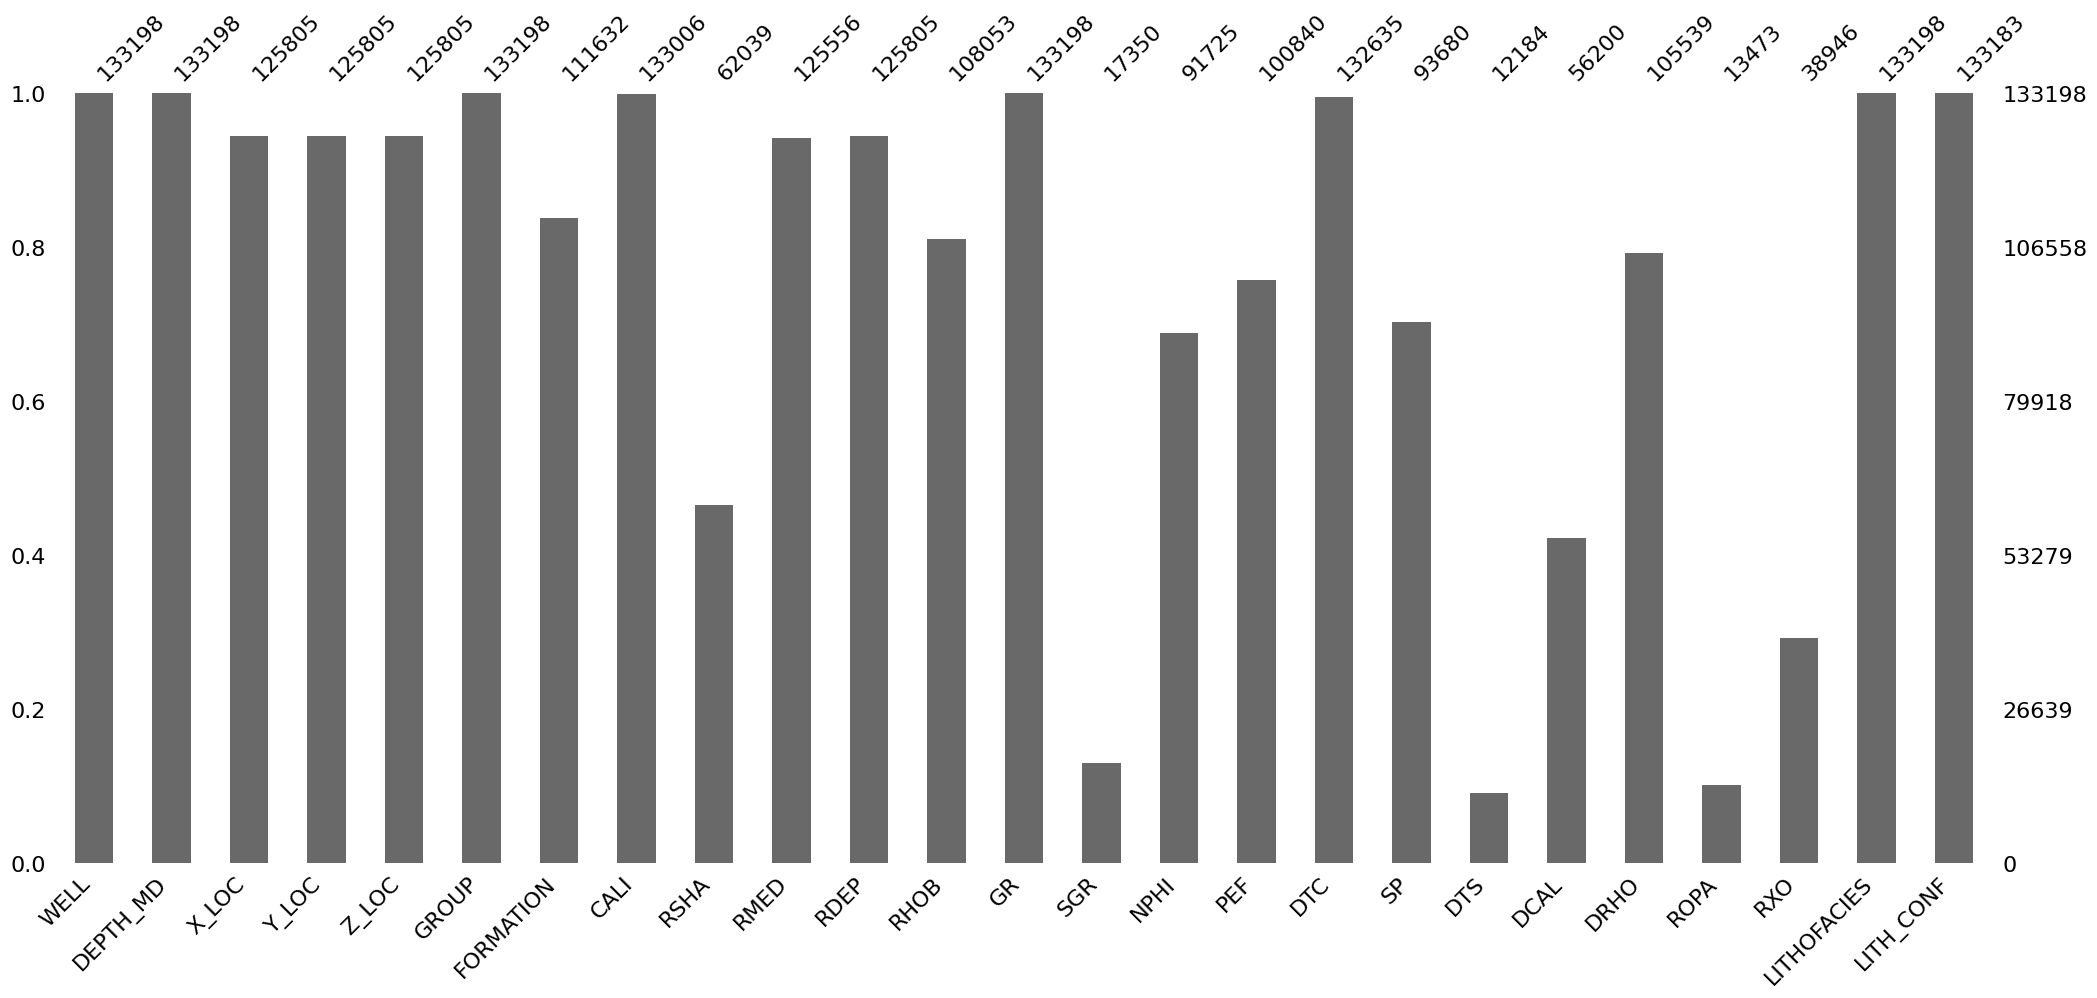

In [13]:
import missingno as msno
import matplotlib.pyplot as plt

msno.bar(df)

<Axes: >

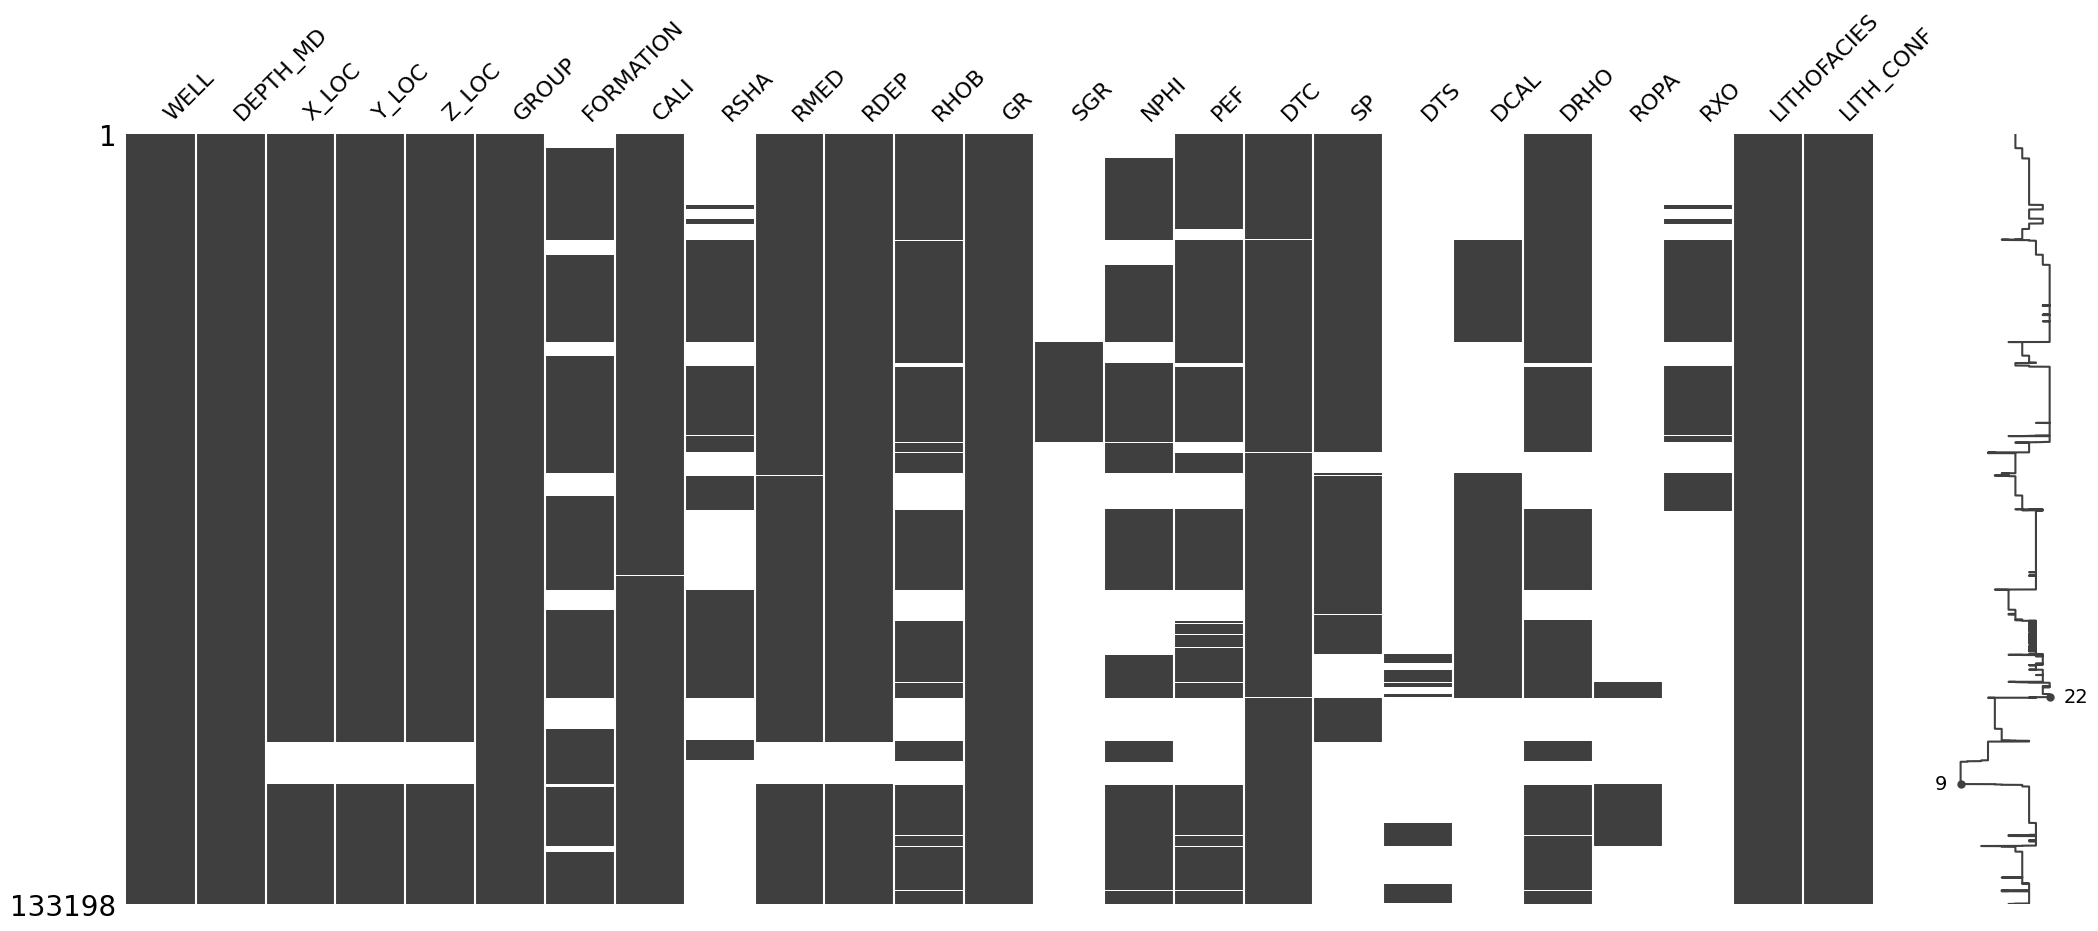

In [16]:
msno.matrix(df)

#### Here u can visulally see the location where data is missing, corellation, patterns, etc

#### the zig zag curve on the right indicates the quantity of missing values row wise: max 22 = max 22 rows are filled 

<Axes: >

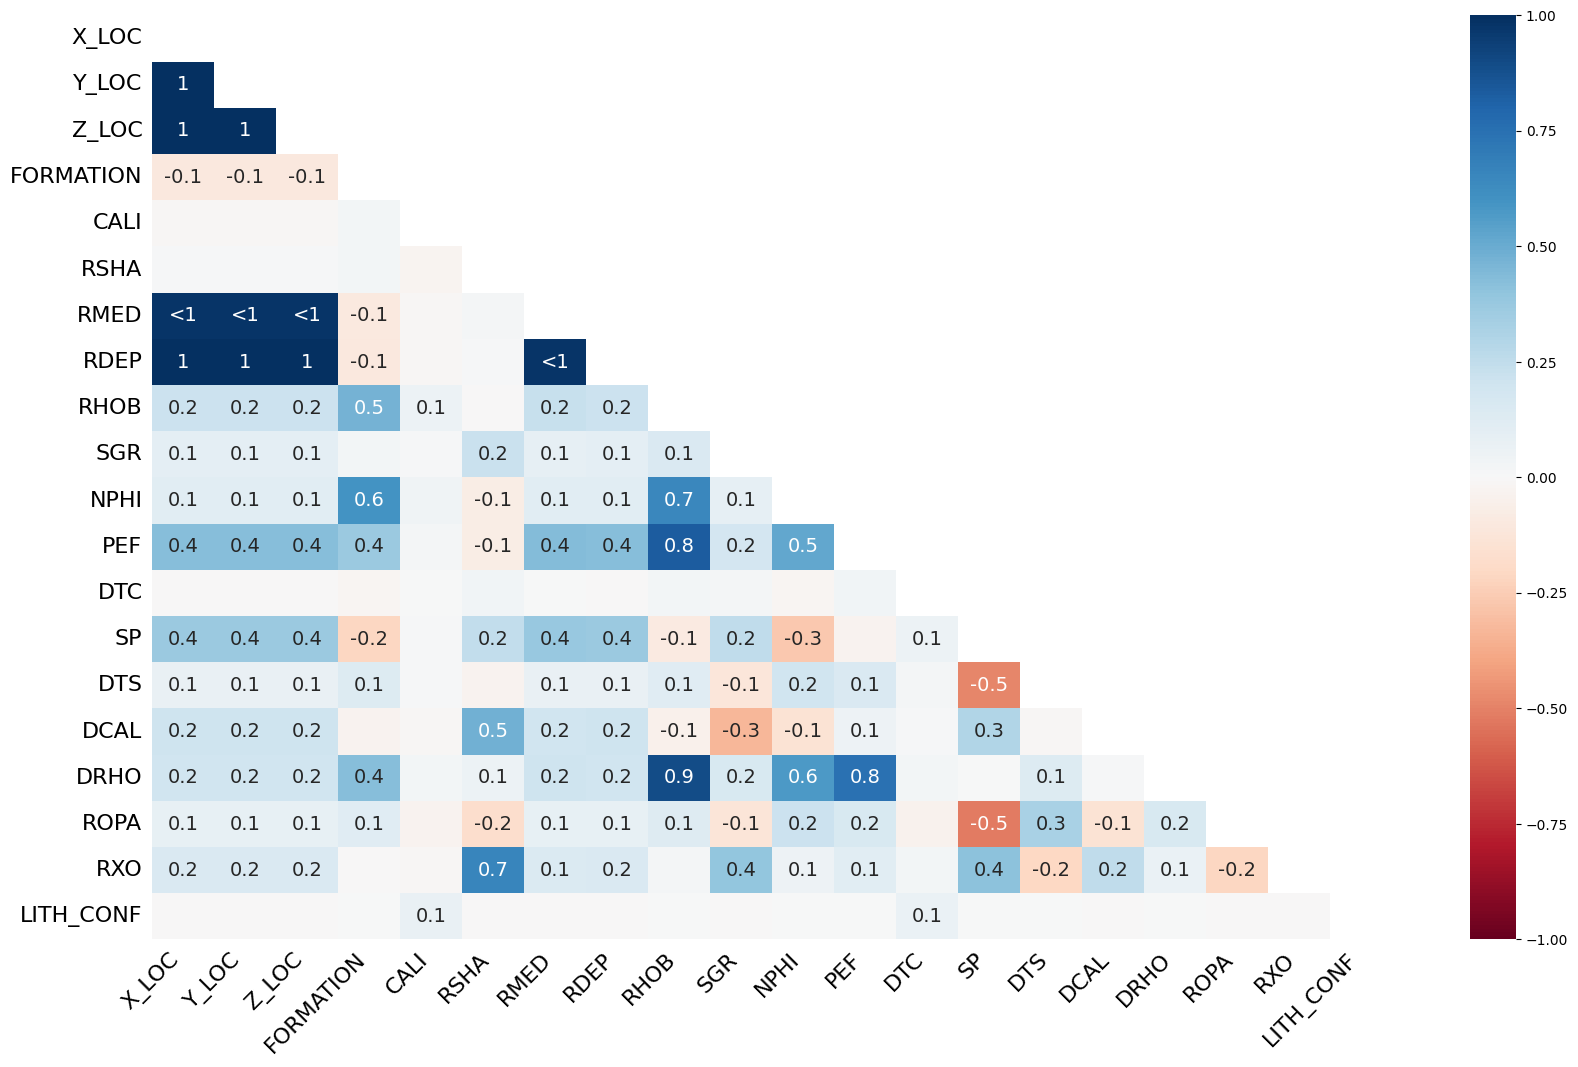

In [17]:
msno.heatmap(df)

#### correlation of "missingness" between two columns

#### DRHO and RHOB has very high corellation so same/similar cols of them are having missing values

#### -iv correlation: -1 = if vlaue appear in 1 col then definately null in other col

<Axes: >

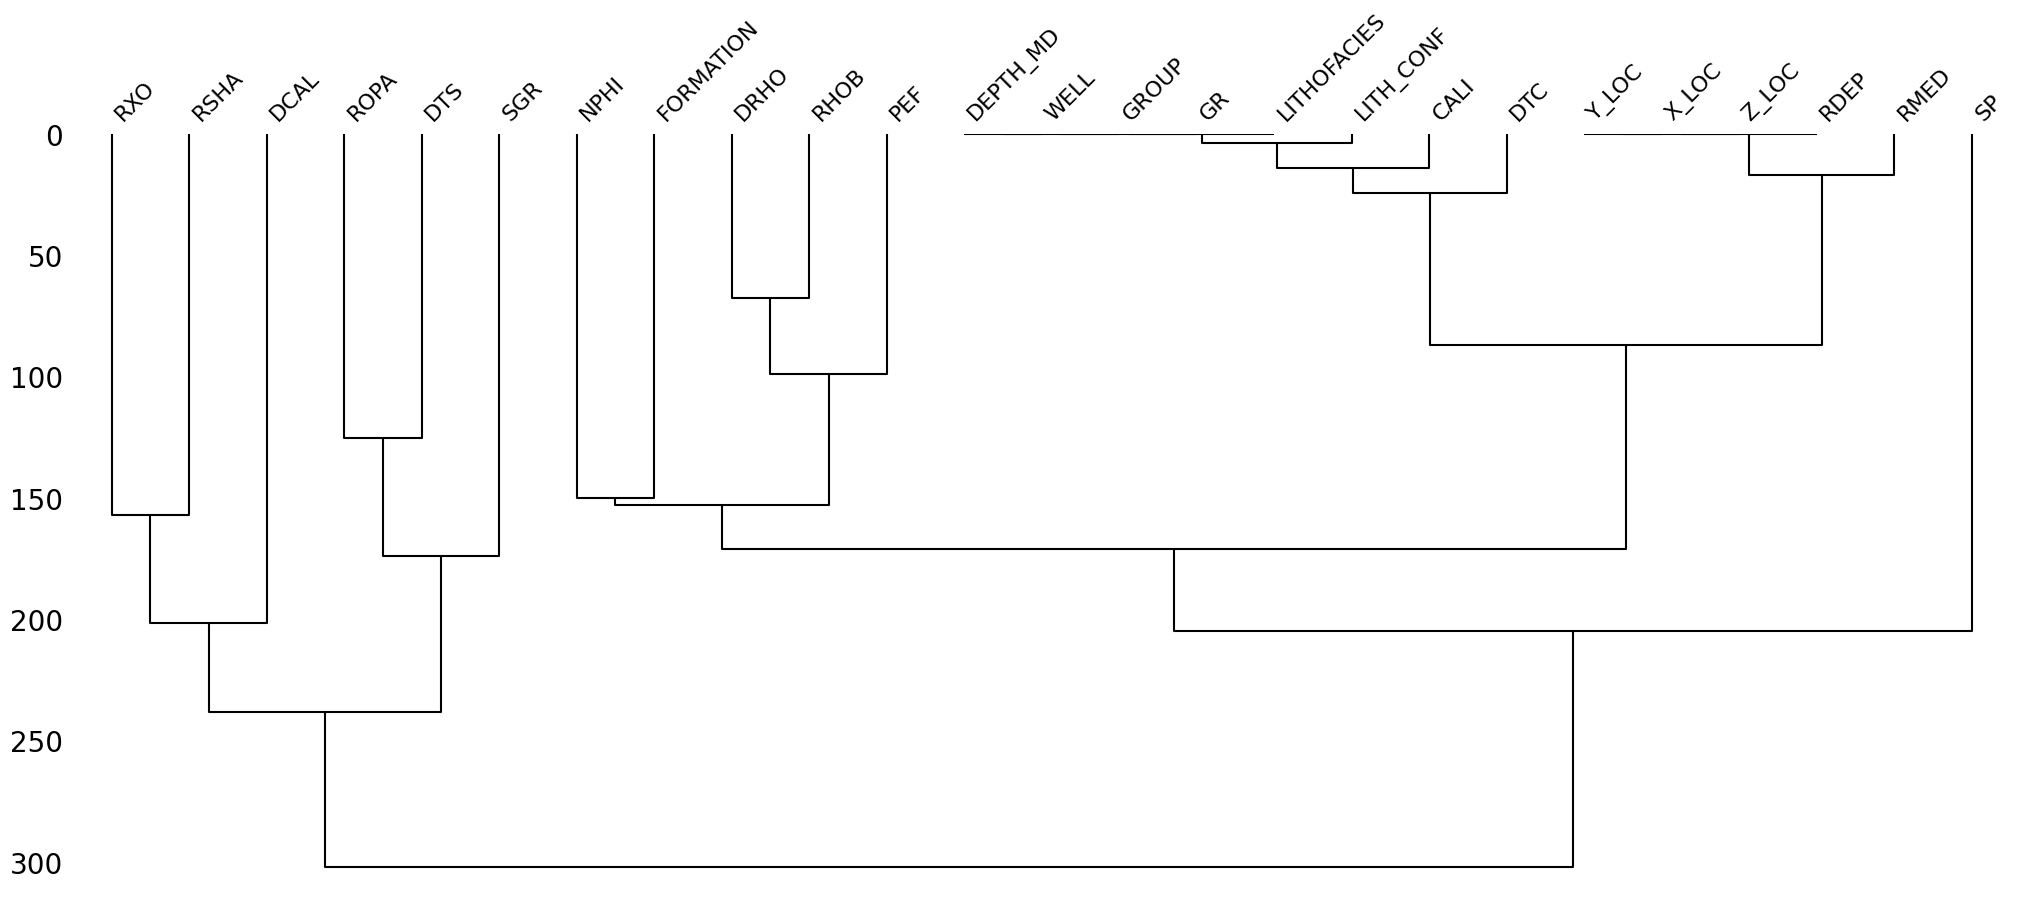

In [19]:
msno.dendrogram(df)

## Study definations of **MCAR**(Missing Completely At Random), **MAR**(Missing At Random), **MMNAR**(Missing Not At Random)

### 1. How to detect MCAR

In [33]:
np.random.seed(67)

data = np.random.randn(100,3)

missing_index_no = np.random.choice(np.arange(100),size=20,replace=False)
data[missing_index_no,0] = np.nan

df = pd.DataFrame(data, columns=['A','B','C'])
df.head()

,A,B,C
0,1.128522,0.144192,-1.115259
1,1.231047,-0.154658,-0.598387
2,NaN,1.220590,-0.828710
3,-1.111059,-0.524290,-1.093422
4,-1.635335,-1.685021,0.692329


* Artificially created dummy **MCAR** data

### Investigation

In [44]:
# Split the data into two gorups
missing_data = df[df['A'].isnull()]
non_missing_data = df[~df['A'].isnull()]

# find mean of both
mean_missing = missing_data.mean()
mean_non_missing = non_missing_data.mean()

In [47]:
mean_non_missing

A   -0.045642
B    0.066317
C   -0.191807
dtype: float64

In [48]:
mean_missing

A         NaN
B   -0.090245
C   -0.267494
dtype: float64

In [56]:
from scipy import stats

t_stat, p_val = stats.ttest_ind(missing_data['B'],non_missing_data['B'],nan_policy='omit')


In [57]:
t_stat

np.float64(-0.6761207804295312)

In [58]:
p_val

np.float64(0.5005564975842975)

#### since, p_val > 0.05 thus, we cant proof that its MAR(this hypothesis is rejected)

<Axes: >

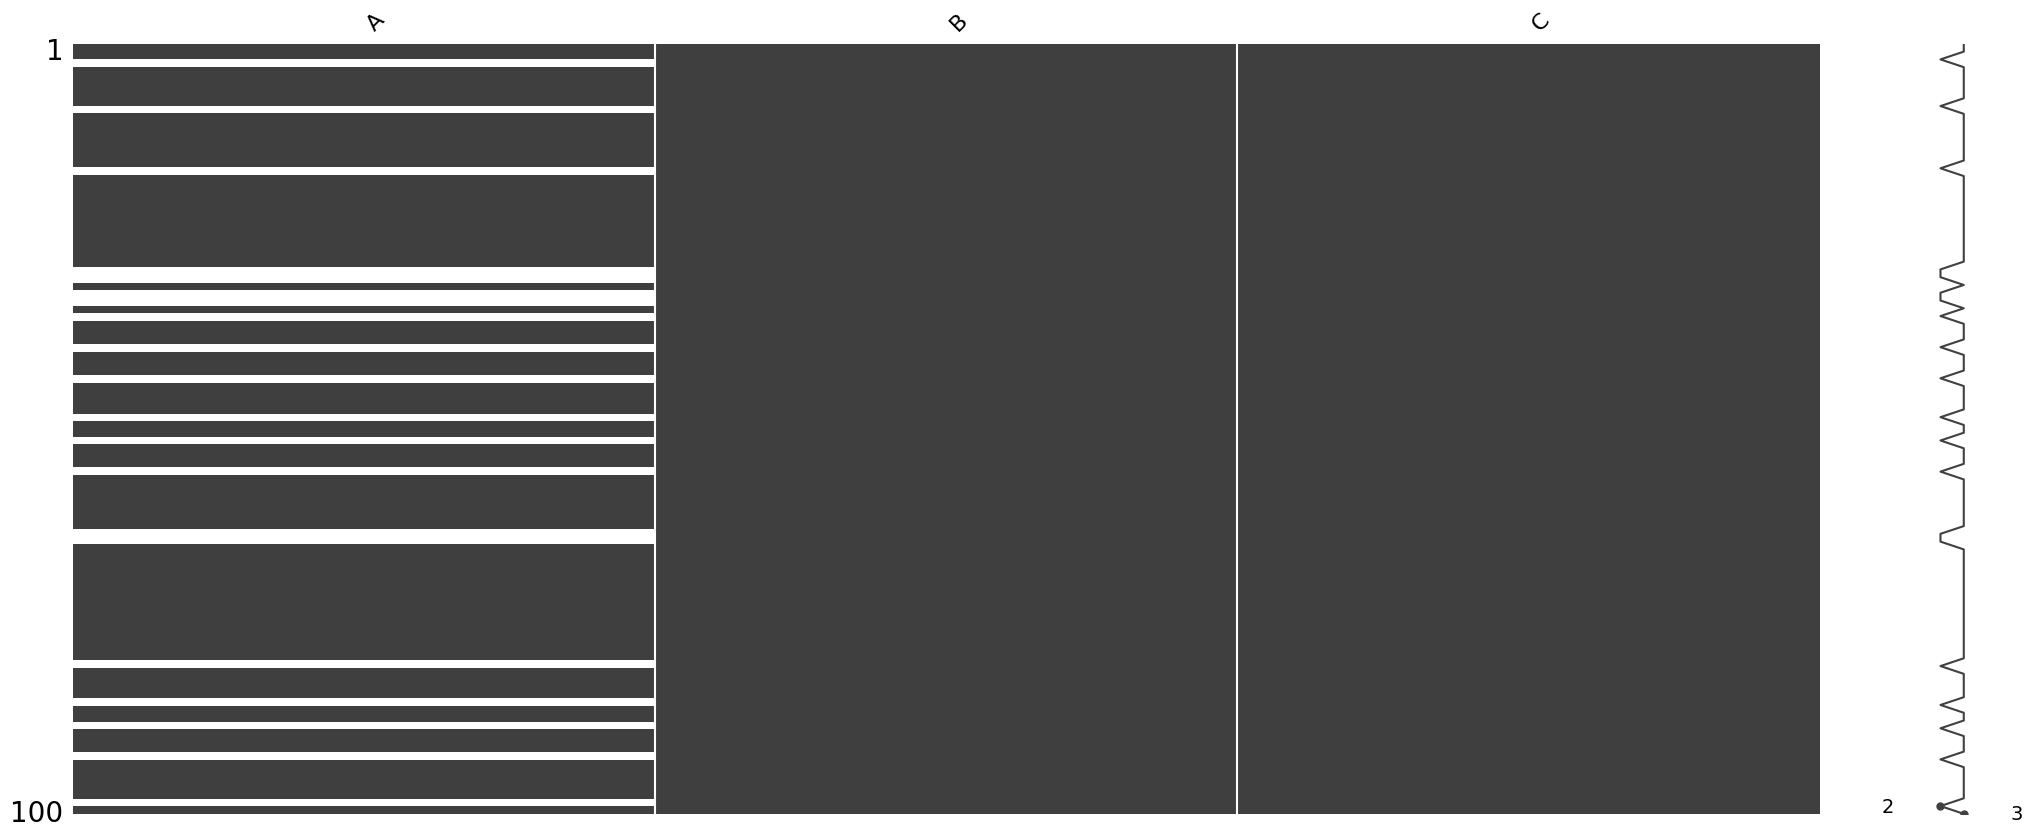

In [59]:
msno.matrix(df)

#### missingness is scattered so it signifies that its more inclined towards **MCAR**

### 2. How to detect MAR

#### Generate feature 1 dependent to feature 2

In [72]:
import numpy as np
import pandas as pd

# Set random seed for reproducibility
np.random.seed(42)

# Generate synthetic data
n_samples = 100
f2 = np.random.randn(n_samples)  # Feature 2: Normal distribution
f3 = np.random.rand(n_samples) * 100  # Feature 3: Uniform distribution between 0 and 100

# Generate Feature 1 with a dependency on Feature 2 for missingness
f1 = np.random.randn(n_samples) * 50  # Initial Feature 1: Normal distribution, scaled
# Introduce missing values in f1 based on f2; higher values of f2 are more likely to result in missing f1 values
missing_probability = (f2 - f2.min()) / (f2.max() - f2.min())  # Normalize f2 to get probabilities
f1[missing_probability > 0.8] = np.nan  # Set f1 to NaN where missing_probability > 0.8

# Create DataFrame
df = pd.DataFrame({'Feature1': f1, 'Feature2': f2, 'Feature3': f3})

df.head()

,Feature1,Feature2,Feature3
0,0.650095,0.496714,41.741100
1,72.676704,-0.138264,22.210781
2,-13.232842,0.647689,11.986537
3,NaN,1.523030,33.761517
4,31.283367,-0.234153,94.290970


In [73]:
df.isnull().sum()

Feature1    13
Feature2     0
Feature3     0
dtype: int64

<Axes: >

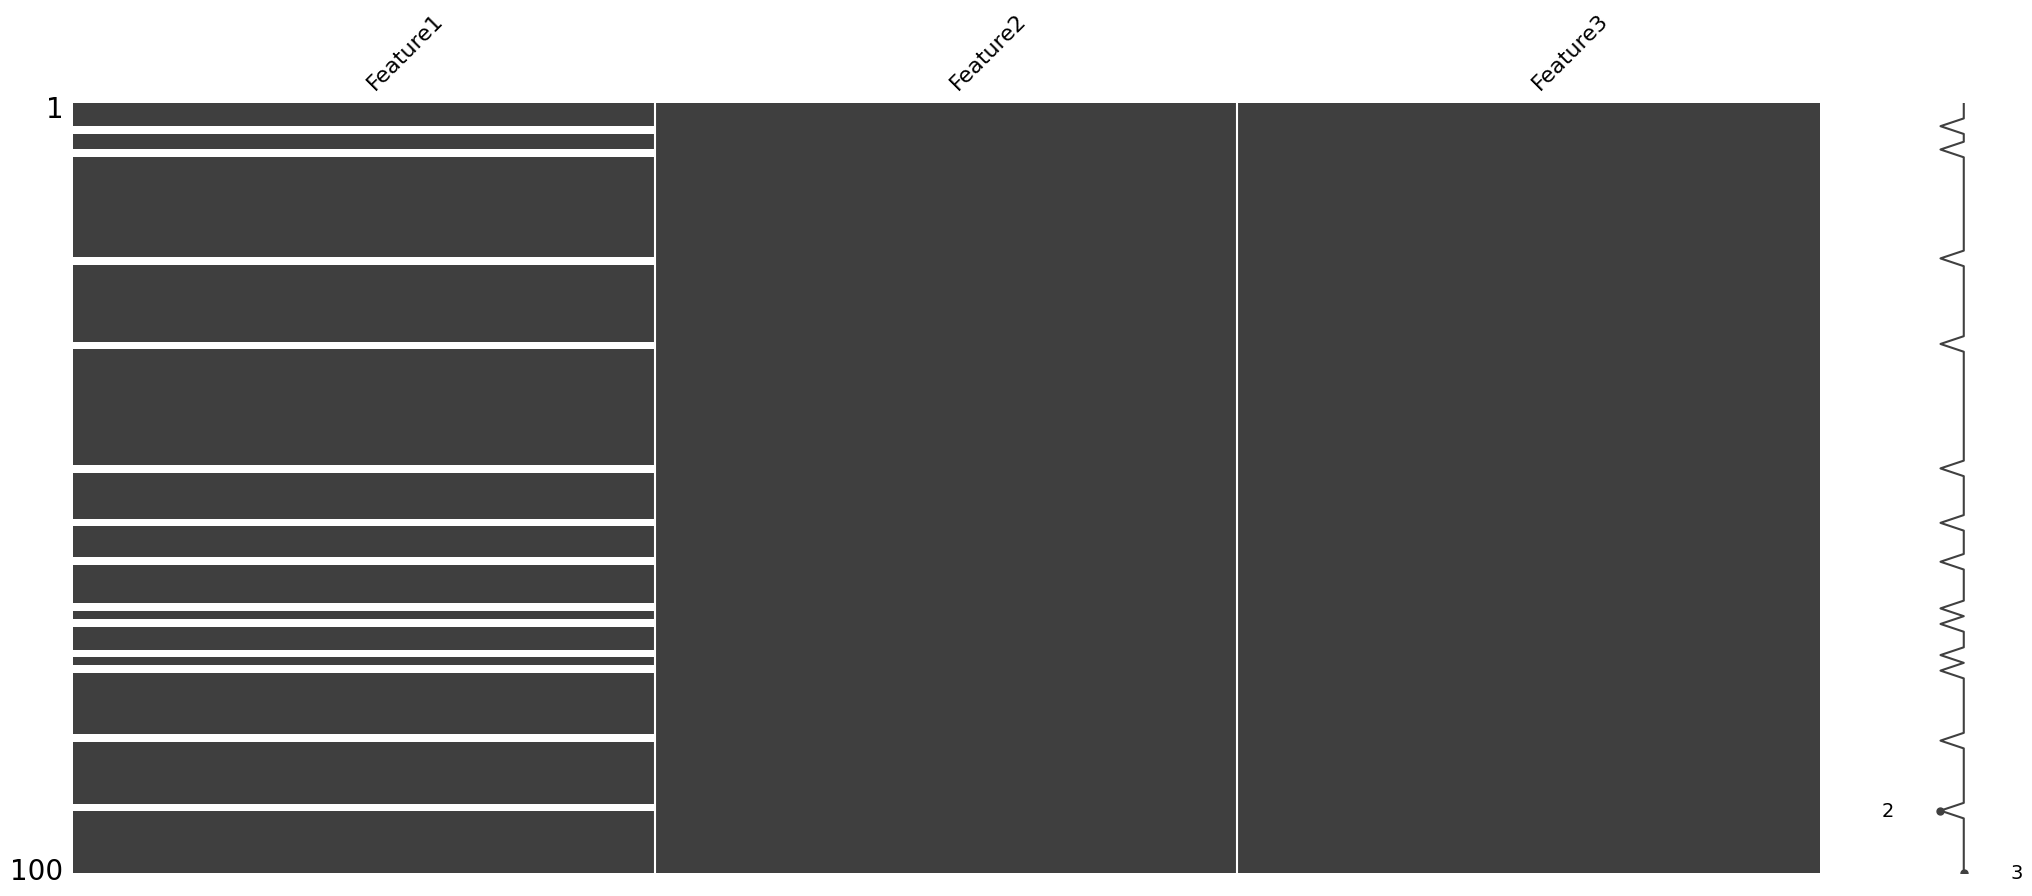

In [74]:
msno.matrix(df)

#### in the bottom-middle the missing data is more frequent indicating towards MCAR

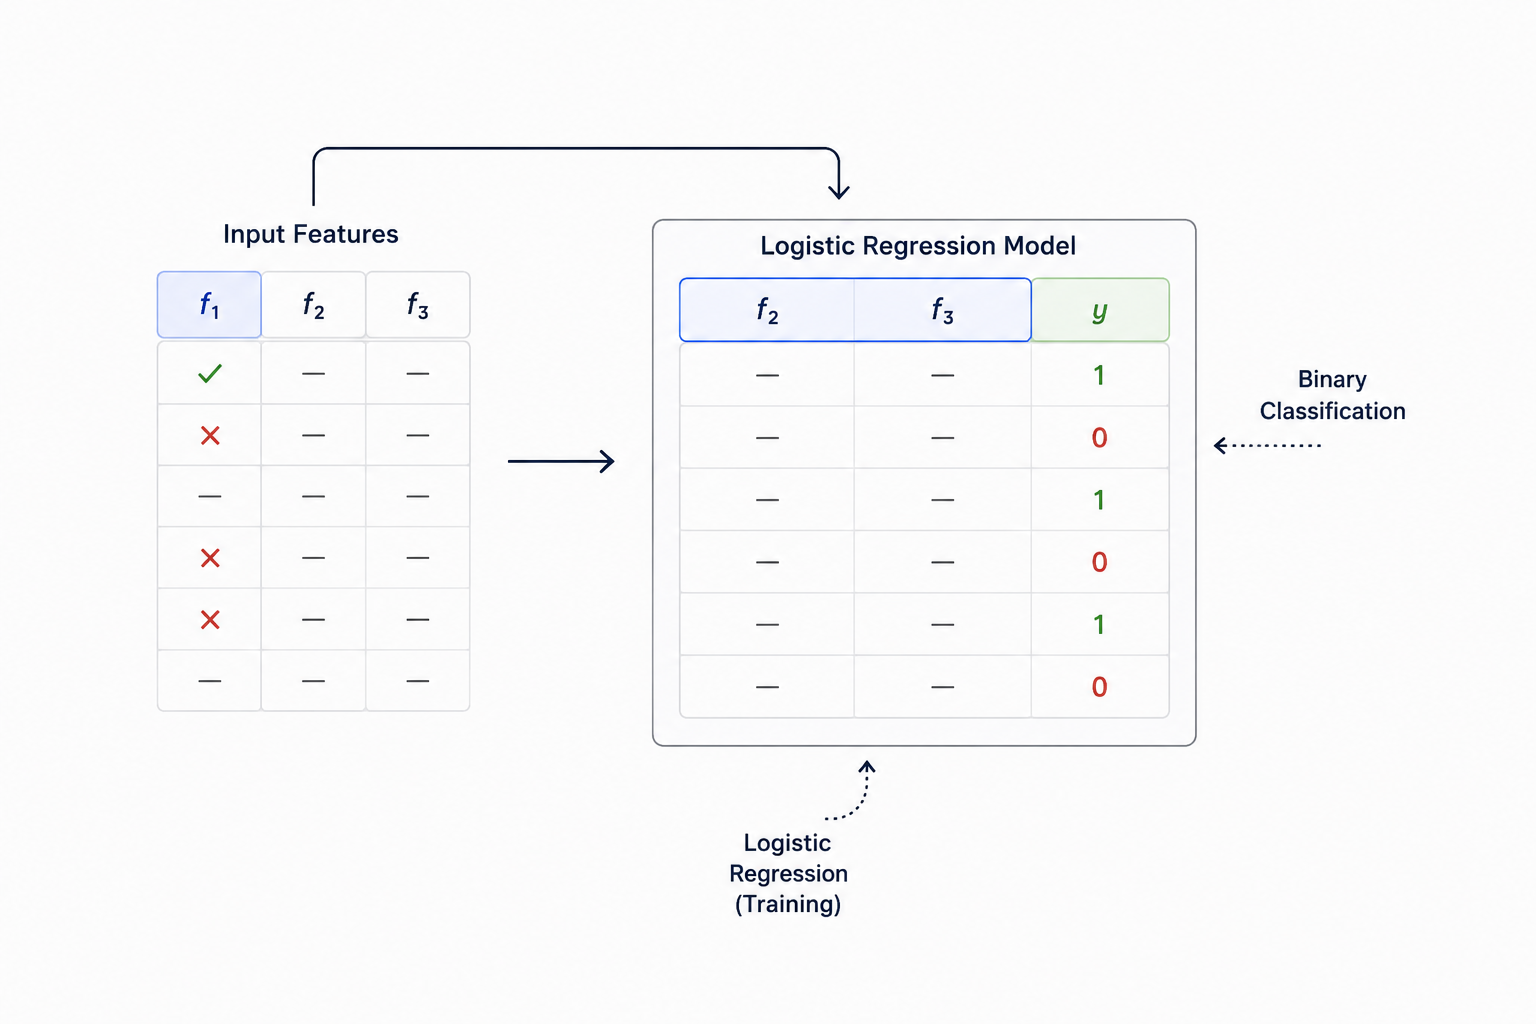

In [92]:
df['Feature_missing'] = df['Feature1'].isnull().astype(int)

In [93]:
 df

,Feature1,Feature2,Feature3,Feature_missing
0,0.650095,0.496714,41.741100,0
1,72.676704,-0.138264,22.210781,0
2,-13.232842,0.647689,11.986537,0
3,NaN,1.523030,33.761517,1
4,31.283367,-0.234153,94.290970,0
...,...,...,...,...
95,-71.793108,-1.463515,24.398964,0
96,58.158188,0.296120,97.301055,0
97,0.511653,0.261055,39.309772,0
98,-49.075433,0.005113,89.204656,0


In [99]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X = df[['Feature2','Feature3']]
Y = df['Feature_missing']

X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=67)

m = LogisticRegression()

m.fit(X_train,Y_train)

pred = m.predict(X_test)

accuracy_score(pred,Y_test)

0.95

### This high accuracy score indicate towards **MAR**

In [101]:
m.coef_

array([[2.79022641, 0.0045004 ]])

* Very dependent on `feature2`

## visualize the distributions of 'Feature2' and 'Feature3' based on whether 'Feature1' has missing values

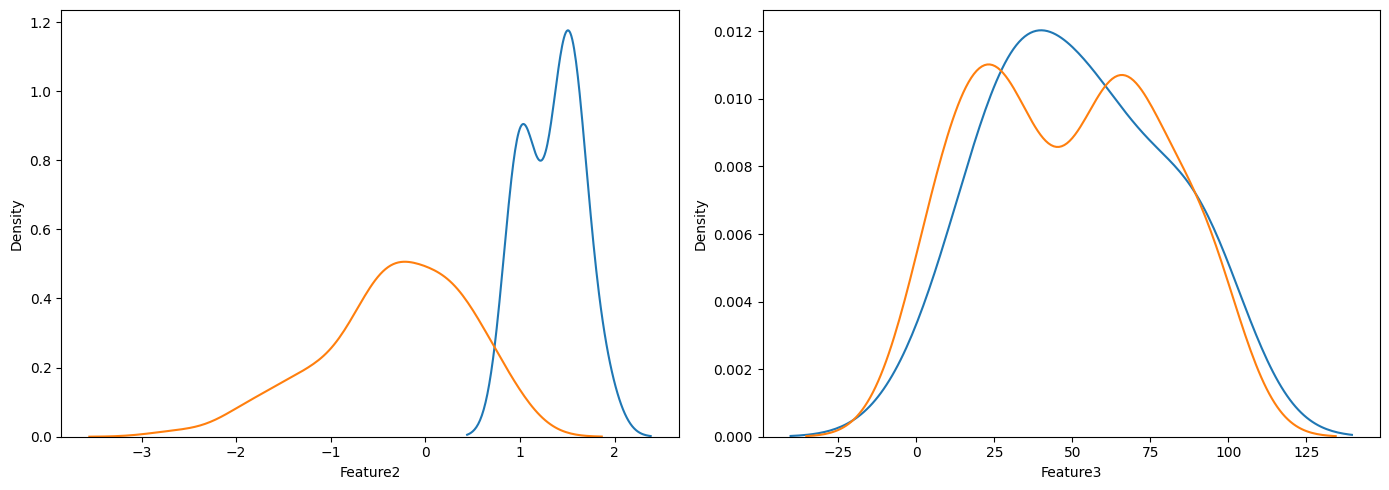

In [120]:
import seaborn as sns

# Split the data into two gorups
group_with_missing = df[df['Feature1'].isnull()]
group_without_missing = df[~df['Feature1'].isnull()]

fig, axes = plt.subplots(1,2, figsize=(14,5))

sns.kdeplot(group_with_missing['Feature2'],ax=axes[0])
sns.kdeplot(group_without_missing['Feature2'],ax=axes[0])

sns.kdeplot(group_with_missing['Feature3'])
sns.kdeplot(group_without_missing['Feature3'])

plt.tight_layout()

### Feature2 with corresponding to null and non null feature1 values are drastically different therefore it can be **MAR**

## Handling Missing Values

#### Methods to Handle Missingness
1. **Remove:** Drop the rows or columns containing missing values.
2. **Impute:** Fill in missing values using statistical techniques (Mean, Median, Mode, MICE, KNN, etc.).
3. **Use Robust Algorithms:** Use models that natively handle missing values without prior preprocessing (e.g., XGBoost, LightGBM).

---

### How to Decide?

The decision-making process depends on three main pillars:

#### 1. Mechanism of Missingness
* **MCAR (Missing Completely at Random):** Missingness has no relationship with any data. 
  * **Action:** **Remove** (since dropping rows keeps the distribution intact) or **Impute**.
* **MAR (Missing at Random):** Missingness is related to other observed variables, but not the missing data itself.
  * **Action:** **Impute**.
* **MNAR (Missing Not at Random):** Missingness depends on the unobserved missing value itself (e.g., high-income people refusing to reveal salary).
  * **Action:** Flag the missingness explicitly or use advanced modeling.

#### 2. Amount of Missing Data
* If a single column has **90% of its values missing**, remove that entire column.

#### 3. Type of Data
* Strategy shifts depending on whether the column is **Categorical** (Impute with Mode or 'Missing' label) or **Continuous** (Impute with Mean/Median).

#### 4. Model Being Used
* **XGBoost / LightGBM:** If only a small amount of data is missing, you can try running the model without handling missing values at all.
* **Linear Regression:** Opposite behavior—linear models cannot handle missing values and will fail/drop accuracy completely if not explicitly handled first.


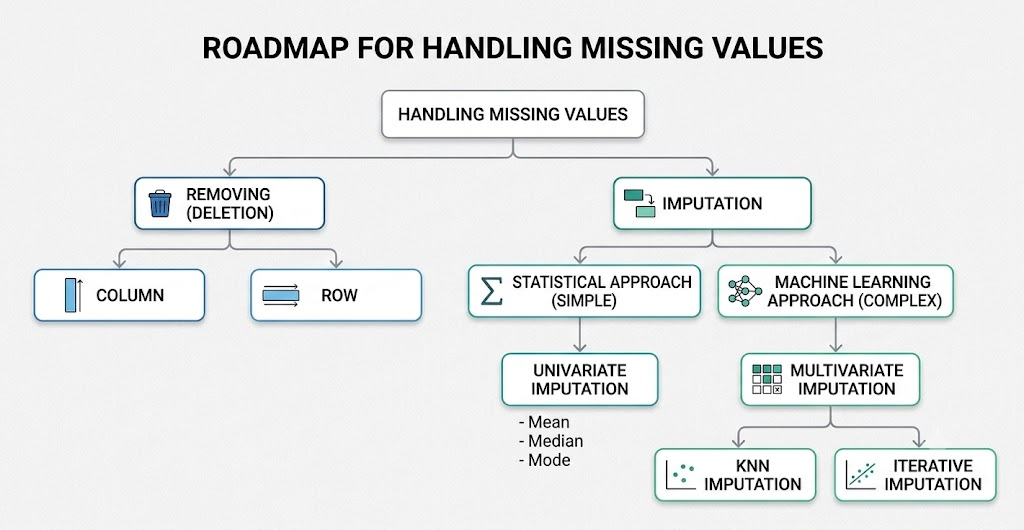